<a href="https://colab.research.google.com/github/limarceloaugusto133/lia1_2026_2/blob/main/Classifica%C3%A7%C3%A3o_de_alimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍕 Classificação de Alimentos com Deep Learning — Food-101 (subconjunto)

**Disciplina/Tema:** Visão Computacional — Redes Neurais Convolucionais (CNN)
**Stack:** TensorFlow / Keras + TensorFlow Datasets (TFDS)
**Dataset:** [Food-101](https://www.tensorflow.org/datasets/catalog/food101) — subconjunto de **12 classes**

---

## 🎤 Slide 1 — Contexto e Motivação

Classificação de imagens de alimentos é um problema real e amplamente aplicado:

- 📱 **Apps de nutrição** (ex.: MyFitnessPal, contadores de calorias) — reconhecer o prato pela foto;
- 🍽️ **Delivery e varejo alimentício** — categorizar automaticamente fotos enviadas por usuários/parceiros;
- 🏭 **Controle de qualidade industrial** — verificar se o prato/produto final corresponde ao esperado;
- 🩺 **Saúde** — sistemas de acompanhamento alimentar para pacientes.

o **Food-101** traz um desafio
realista: fotos tiradas por pessoas comuns, com variação de ângulo, iluminação, fundo e composição do prato.

## 🎤 Slide 2 — Pipeline do Projeto

```
Dados (TFDS) → Filtragem de classes → Pré-processamento → Modelo (CNN) →
Treinamento + Validação → Avaliação → Inferência
```

## 🎤 Slide 3 — Sobre o dataset escolhido

O **Food-101** completo tem **101 classes** e **101.000 imagens** (75.750 treino / 25.250 validação),
com ~4,65 GB de download. Para um projeto didático, com tempo de treino compatível com o Colab,
selecionamos um **subconjunto de 12 classes** bem conhecidas e visualmente distintas:

| # | Classe (inglês) | Exemplo (PT-BR) |
|---|---|---|
| 1 | `pizza` | Pizza |
| 2 | `sushi` | Sushi |
| 3 | `hamburger` | Hambúrguer |
| 4 | `ice_cream` | Sorvete |
| 5 | `french_fries` | Batata frita |
| 6 | `tacos` | Tacos |
| 7 | `donuts` | Rosquinha (donut) |
| 8 | `ramen` | Ramen |
| 9 | `steak` | Bife/Filé |
| 10 | `waffles` | Waffle |
| 11 | `spaghetti_bolognese` | Espaguete à bolonhesa |
| 12 | `chocolate_cake` | Bolo de chocolate |

**📌 Documentação técnica:** o download do Food-101 é feito **por completo** na primeira execução
(o TFDS não permite baixar apenas classes específicas), mas graças ao **cache do TFDS**
(`~/tensorflow_datasets`), esse download só acontece uma vez por ambiente. Depois disso, filtramos
programaticamente apenas as 12 classes de interesse.

> ⚠️ **Aviso de tempo de execução:** o download do Food-101 tem ~4,65 GB. Na primeira execução no Colab,
> reserve alguns minutos para essa etapa antes de seguir para o pré-processamento.


## 1. Bibliotecas + Dados

### 🎯 Objetivo desta etapa
Carregar o dataset Food-101 via TFDS, entender sua estrutura (splits, classes, formato das imagens)
e **filtrar apenas as 12 classes** escolhidas para este projeto.

### 📚 Conceito por trás
O Food-101 é distribuído no TFDS com os splits `train` (750 imagens/classe) e `validation`
(250 imagens/classe). As imagens têm **tamanhos variados** (`shape=(None, None, 3)`), por isso precisaremos padronizar o tamanho na etapa de pré-processamento.

### 🛠️ O que o código faz
1. Importa as bibliotecas;
2. Faz o download/preparo do Food-101 via `tfds.builder` (com cache automático);
3. Lê os metadados (`info`) para obter a lista completa das 101 classes;
4. Faz verificações explícitas de integridade (dataset existe, classes escolhidas realmente existem).


In [ ]:
# Bibliotecas principais
!pip install -q -U protobuf tensorflow_datasets importlib_resources
!pip install -q -U protobuf tensorflow_datasets
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print("GPU disponível:", "Sim ✅" if tf.config.list_physical_devices("GPU") else "Não (rodando em CPU)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 24.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1 which is incompatible.
TensorFlow: 2.20.0
TFDS: 4.9.10
GPU disponível: Sim ✅


In [ ]:
# Download / preparo do Food-101 (executado uma única vez; fica em cache local)
DATASET_NAME = "food101"

try:
    builder = tfds.builder(DATASET_NAME)
    builder.download_and_prepare()
    ds_info = builder.info
except Exception as e:
    raise RuntimeError(
        f"Falha ao preparar o dataset '{DATASET_NAME}'. Verifique a conexão com a internet "
        f"e o espaço em disco disponível (~5 GB necessários). Erro original: {e}"
    )

class_names_full = ds_info.features["label"].names
print(f"Total de classes no Food-101 completo: {len(class_names_full)}")
print(f"Exemplos de classes disponíveis: {class_names_full[:10]} ...")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.5ZPC5W_2.0.0/food101-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.5ZPC5W_2.0.0/food101-validation.tfrecord-[0-9][0-9][0-9…

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
Total de classes no Food-101 completo: 101
Exemplos de classes disponíveis: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito'] ...


In [ ]:
# Seleção do subconjunto de 12 classes de alimentos
SELECTED_CLASSES = [
    "pizza", "sushi", "hamburger", "ice_cream", "french_fries",
    "tacos", "donuts", "ramen", "steak", "waffles",
    "spaghetti_bolognese", "chocolate_cake",
]

# Verificação explícita: todas as classes escolhidas existem no dataset?
classes_invalidas = [c for c in SELECTED_CLASSES if c not in class_names_full]
if classes_invalidas:
    raise ValueError(f"Classes inválidas (não existem no Food-101): {classes_invalidas}")

# Índices originais (0-100) correspondentes às classes escolhidas
selected_indices = [class_names_full.index(c) for c in SELECTED_CLASSES]
num_classes = len(SELECTED_CLASSES)
class_names = SELECTED_CLASSES  # nomes finais usados no restante do notebook

print("✅ Todas as 12 classes selecionadas são válidas.")
print("Índices originais no Food-101:", dict(zip(class_names, selected_indices)))


✅ Todas as 12 classes selecionadas são válidas.
Índices originais no Food-101: {'pizza': 76, 'sushi': 95, 'hamburger': 53, 'ice_cream': 58, 'french_fries': 40, 'tacos': 96, 'donuts': 31, 'ramen': 81, 'steak': 93, 'waffles': 100, 'spaghetti_bolognese': 90, 'chocolate_cake': 21}


In [ ]:
# Carregamento dos splits completos (ainda com as 101 classes) como tf.data.Dataset
# USo do tf.data.Dataset,
# que processa os dados em fluxo (streaming), sem carregar tudo de uma vez na RAM.
ds_train_full = builder.as_dataset(split="train", as_supervised=True)
ds_val_full = builder.as_dataset(split="validation", as_supervised=True)

print("Splits carregados como tf.data.Dataset (streaming).")
print("Elemento de exemplo (imagem, rótulo):", ds_train_full.element_spec)


Splits carregados como tf.data.Dataset (streaming).
Elemento de exemplo (imagem, rótulo): (TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))


### 1.1 Filtragem das classes e remapeamento de rótulos

### 🎯 Objetivo
Manter no dataset apenas as imagens das 12 classes escolhidas, e **remapear os rótulos**
originais (que variam de 0 a 100) para o intervalo `0 a 11`, que é o que a última camada
`Dense(num_classes, softmax)` do nosso modelo espera.

### 📚 Conceito por trás
- `Dataset.filter()` percorre o dataset e mantém apenas os elementos que satisfazem uma condição
  (aqui: o rótulo pertence ao conjunto de índices selecionados).
- Uma **tabela de consulta (`tf.lookup.StaticHashTable`)** faz o mapeamento eficiente
  `índice original → índice novo` diretamente dentro do grafo do TensorFlow (rápido e vetorizado).


In [ ]:
# Tensor com os índices originais válidos (para o filtro)
selected_indices_tensor = tf.constant(selected_indices, dtype=tf.int64)

def filtro_classes(imagem, rotulo):
    '''Mantém apenas exemplos cujo rótulo está entre as classes selecionadas.'''
    return tf.reduce_any(tf.equal(rotulo, selected_indices_tensor))

# Tabela de remapeamento: índice original (0-100) -> índice novo (0-11)
chaves = tf.constant(selected_indices, dtype=tf.int64)
valores = tf.constant(list(range(num_classes)), dtype=tf.int64)
tabela_remapeamento = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(chaves, valores),
    default_value=-1,
)

def remapear_rotulo(imagem, rotulo):
    '''Converte o rótulo original (0-100) para o novo intervalo (0-11).'''
    return imagem, tabela_remapeamento.lookup(rotulo)

# Aplicação: filtra e depois remapeia os rótulos
ds_train_filtrado = ds_train_full.filter(filtro_classes).map(
    remapear_rotulo, num_parallel_calls=tf.data.AUTOTUNE
).cache()

ds_val_filtrado = ds_val_full.filter(filtro_classes).map(
    remapear_rotulo, num_parallel_calls=tf.data.AUTOTUNE
).cache()

print("✅ Filtragem e remapeamento configurados (execução preguiçosa/lazy do tf.data).")


✅ Filtragem e remapeamento configurados (execução preguiçosa/lazy do tf.data).


In [ ]:
# ---------------------------------------------------------------------------
# Contagem real de exemplos por split (após filtragem)
# ---------------------------------------------------------------------------
# Observação: como o tf.data é "lazy" (preguiçoso), precisamos percorrer o dataset
# uma vez para contar quantos exemplos restaram após o filtro. Isso pode levar
# alguns segundos, mas é feito apenas nesta verificação.
qtd_treino = sum(1 for _ in ds_train_filtrado)
qtd_validacao = sum(1 for _ in ds_val_filtrado)

print(f"Exemplos de treino (12 classes)    : {qtd_treino}")
print(f"Exemplos de validação (12 classes) : {qtd_validacao}")

esperado_treino = num_classes * 750
esperado_validacao = num_classes * 250

if qtd_treino != esperado_treino or qtd_validacao != esperado_validacao:
    print(
        f"⚠️ Contagem diferente do esperado (treino esperado={esperado_treino}, "
        f"validação esperado={esperado_validacao}). Prosseguindo mesmo assim."
    )
else:
    print("✅ Contagem de exemplos confere com o esperado (750 treino / 250 validação por classe).")


Exemplos de treino (12 classes)    : 9000
Exemplos de validação (12 classes) : 3000
✅ Contagem de exemplos confere com o esperado (750 treino / 250 validação por classe).


## 2. Visualização dos Dados

### 🎯 Objetivo desta etapa
Olhar diretamente para as imagens antes de treinar qualquer modelo — isso ajuda a:
- Confirmar visualmente que os rótulos fazem sentido;
- Perceber a variabilidade real das fotos (ângulo, fundo, iluminação);
- Verificar se as classes estão balanceadas.



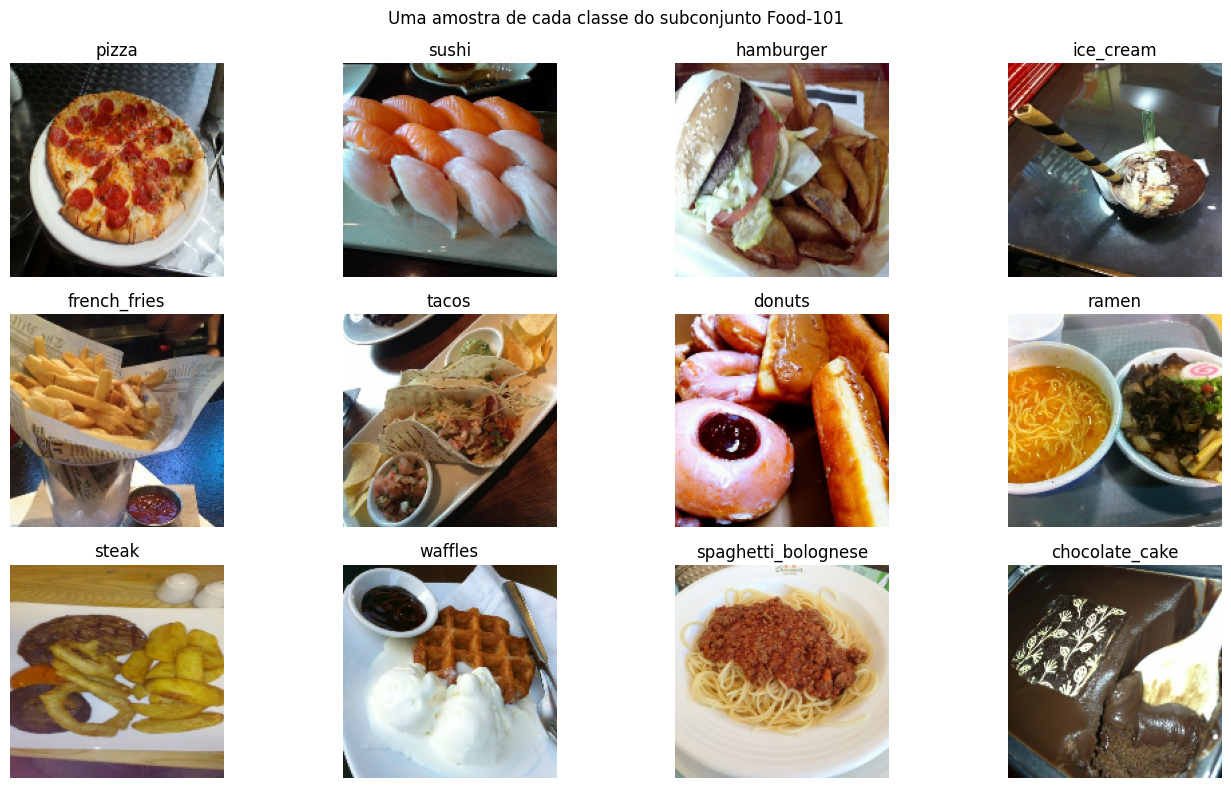

In [ ]:
# Amostra visual: uma imagem de cada uma das 12 classes selecionadas
IMG_DISPLAY_SIZE = 160

amostras_por_classe = {}
for imagem, rotulo in ds_train_filtrado:
    r = int(rotulo.numpy())
    if r not in amostras_por_classe:
        amostras_por_classe[r] = imagem
    if len(amostras_por_classe) == num_classes:
        break

plt.figure(figsize=(14, 8))
for i in range(num_classes):
    imagem = tf.image.resize(amostras_por_classe[i], [IMG_DISPLAY_SIZE, IMG_DISPLAY_SIZE])
    plt.subplot(3, 4, i + 1)
    plt.imshow(imagem.numpy().astype("uint8"))
    plt.title(class_names[i])
    plt.axis("off")

plt.suptitle("Uma amostra de cada classe do subconjunto Food-101")
plt.tight_layout()
plt.show()


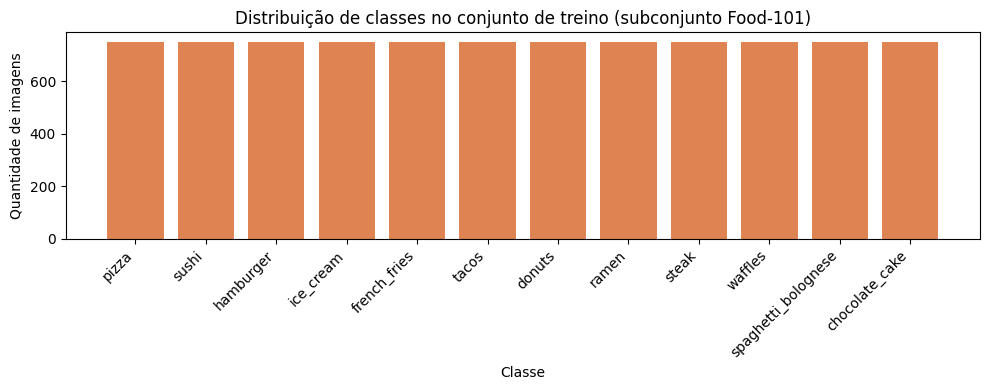

Menor classe: 750 | Maior classe: 750
✅ Classes bem balanceadas (o Food-101 já é balanceado por construção: 750 img/classe).


In [ ]:
# ---------------------------------------------------------------------------
# Distribuição das classes: verificar se o subconjunto está balanceado
# ---------------------------------------------------------------------------
rotulos_treino = np.array([int(r.numpy()) for _, r in ds_train_filtrado])
valores, contagens = np.unique(rotulos_treino, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([class_names[v] for v in valores], contagens, color="#DD8452")
plt.title("Distribuição de classes no conjunto de treino (subconjunto Food-101)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Menor classe:", contagens.min(), "| Maior classe:", contagens.max())
if contagens.max() / contagens.min() > 1.2:
    print("⚠️ Atenção: pequeno desbalanceamento entre classes.")
else:
    print("✅ Classes bem balanceadas (o Food-101 já é balanceado por construção: 750 img/classe).")


## 3. Pré-processamento

### 🎯 Objetivo desta etapa
Preparar as imagens para entrarem no modelo de forma padronizada e eficiente, e criar um
**pipeline `tf.data`** otimizado — uma melhoria importante em relação a carregar tudo em um array
NumPy (inviável aqui, pois o Food-101 não cabe inteiro na RAM do Colab).

### 📚 Conceitos por trás de cada transformação

| Transformação | O que faz | Por que é necessária |
|---|---|---|
| `tf.image.resize` | Padroniza todas as imagens para `96x96` | O modelo exige um shape de entrada fixo |
| Normalização (`/255.0`) | Reescala pixels de `[0, 255]` para `[0, 1]` | Redes neurais convergem melhor com entradas pequenas e centradas |
| **Data augmentation** | Aplica flips, rotações e zooms aleatórios *apenas no treino* | Aumenta artificialmente a variabilidade dos dados e reduz overfitting — importante aqui, pois temos poucas imagens por classe (750) |
| `.cache()` | Guarda em memória/disco o resultado do pré-processamento | Evita reprocessar (decodificar/redimensionar) a mesma imagem a cada época |
| `.shuffle()` | Embaralha a ordem dos exemplos | Evita que o modelo aprenda um viés relacionado à ordem dos dados |
| `.batch()` | Agrupa exemplos em lotes | Necessário para treinar de forma eficiente em GPU/CPU |
| `.prefetch(AUTOTUNE)` | Prepara o próximo lote enquanto o atual está sendo processado pelo modelo | Reduz tempo ocioso da GPU/CPU esperando dados |

### 🛠️ O que o código faz
Define as funções de redimensionamento/normalização e o bloco de *data augmentation*,
depois monta os pipelines finais de treino e validação.


In [ ]:
IMG_SIZE = 96          # tamanho final das imagens (96x96 pixels, 3 canais)
BATCH_SIZE = 32

def preprocessar(imagem, rotulo):
    '''Redimensiona e normaliza uma imagem para o intervalo [0, 1].'''
    imagem = tf.image.resize(imagem, [IMG_SIZE, IMG_SIZE])
    imagem = tf.cast(imagem, tf.float32) / 255.0
    return imagem, rotulo

# Data augmentation: aplicado SOMENTE no conjunto de treino
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

print(f"Imagens serão redimensionadas para {IMG_SIZE}x{IMG_SIZE}x3.")
print(f"Tamanho do lote (batch): {BATCH_SIZE}")


Imagens serão redimensionadas para 96x96x3.
Tamanho do lote (batch): 32


In [ ]:

# Pipeline de treino: filtro -> preprocessamento -> cache -> shuffle -> batch ->
#                     augmentation -> prefetch
train_ds = (
    ds_train_filtrado
    .map(preprocessar, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(2000, seed=SEED)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# O split "validation" oficial do Food-101 será dividido em duas metades:
#   - metade para acompanhar o treinamento (val_ds)
#   - metade reservada, intocada, para a avaliação final (test_ds)
# Isso evita "vazamento de informação": o conjunto de teste final nunca influencia
# nenhuma decisão tomada durante o treinamento (ex.: early stopping).
val_full_preprocessado = (
    ds_val_filtrado
    .map(preprocessar, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(qtd_validacao, seed=SEED, reshuffle_each_iteration=False)
)

metade = qtd_validacao // 2
val_ds = (
    val_full_preprocessado.take(metade)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    val_full_preprocessado.skip(metade)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("✅ Pipelines criados: train_ds (treino), val_ds (validação), test_ds (teste final).")
print(f"   ~{metade} imagens em val_ds e ~{qtd_validacao - metade} imagens em test_ds.")


✅ Pipelines criados: train_ds (treino), val_ds (validação), test_ds (teste final).
   ~1500 imagens em val_ds e ~1500 imagens em test_ds.


## 4. Construção do Modelo

### 🎯 Objetivo desta etapa
Construir uma CNN adequada à complexidade do Food-101 por se
tratar de fotos reais, com muito mais variação visual dentro de cada classe.

### 📚 Arquitetura e justificativas (documentação técnica)

| Camada | Parâmetros | Papel |
|---|---|---|
| `Conv2D` | 32 filtros, 3x3, ReLU | Extrai características básicas (bordas, texturas, cores) |
| `MaxPooling2D` | 2x2 | Reduz dimensão espacial, mantendo as características mais fortes |
| `Conv2D` | 64 filtros, 3x3, ReLU | Combina características básicas em padrões mais complexos (formas, texturas de alimentos) |
| `MaxPooling2D` | 2x2 | Reduz dimensão novamente |
| `Conv2D` **(melhoria)** | 128 filtros, 3x3, ReLU | Camada extra para capturar padrões de alto nível — necessária pois as imagens (96x96) e a variabilidade visual do Food-101 |
| `MaxPooling2D` | 2x2 | Reduz dimensão novamente |
| `Flatten` | — | Converte o mapa de características 2D em vetor 1D |
| `Dropout(0.4)` **(melhoria)** | taxa 0.4 | Regularização: "desliga" 40% dos neurônios aleatoriamente a cada passo de treino, reduzindo overfitting |
| `Dense` | 64, ReLU | Combinações não-lineares de alto nível das features extraídas |
| `Dense` (saída) | `num_classes`, Softmax | Gera uma probabilidade para cada uma das 12 classes |

> 💡 **Por que essas melhorias em relação a uma CNN "mínima"?** O Food-101 tem fotos reais tiradas por
> pessoas diferentes, com iluminação e composição variadas — isso exige mais capacidade de
> representação (camada extra) e mais regularização (dropout).

### 🛠️ O que o código faz
Monta o modelo `Sequential`, compila com otimizador Adam e mostra o resumo da arquitetura.


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),  # melhoria: mais capacidade
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.4),  # melhoria: regularização contra overfitting

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       819,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 913,292 (3.48 MB)

 Trainable params: 913,292 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Treinamento + Validação

### 🎯 Objetivo desta etapa
Treinar o modelo usando o `train_ds`, acompanhando o desempenho em `val_ds` a cada época.

### 📚 Melhoria: `EarlyStopping`
Diferente do notebook anterior (número fixo de épocas), aqui usamos o callback
`EarlyStopping`, que **interrompe o treinamento automaticamente** quando a loss de validação
para de melhorar por algumas épocas seguidas (`patience`), e **restaura os melhores pesos**
encontrados durante o treino. Isso evita treinar além do ponto ideal (overfitting) e economiza tempo.

### 📌 Sugestão de hiperparâmetros
- **Épocas máximas:** 20 ;
- **Patience:** 3 épocas sem melhora na `val_loss`.


In [ ]:
EPOCHS_MAXIMO = 20

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MAXIMO,
    callbacks=[early_stopping],
)

epocas_treinadas = len(history.history["loss"])
print(f"\nTreinamento finalizado após {epocas_treinadas} época(s) "
      f"(máximo configurado: {EPOCHS_MAXIMO}).")


Epoch 1/20
    282/Unknown 27s 71ms/step - accuracy: 0.1603 - loss: 2.3746

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.2056 - loss: 2.2778 - val_accuracy: 0.2813 - val_loss: 2.1046
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.2963 - loss: 2.0769 - val_accuracy: 0.3167 - val_loss: 2.0171
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.3323 - loss: 1.9842 - val_accuracy: 0.2913 - val_loss: 2.0418
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.3629 - loss: 1.9016 - val_accuracy: 0.3840 - val_loss: 1.8487
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.3933 - loss: 1.8304 - val_accuracy: 0.3533 - val_loss: 1.8876
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.4249 - loss: 1.7448 - val_accuracy: 0.4407 - val_loss: 1.6925
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.4377 - loss: 1.6840 - val_accuracy: 0.4287 - val_loss: 1.6997
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.4592 - loss: 1.6298 - val_accurac

## 6. Avaliação do Modelo

### 🎯 Objetivo desta etapa
Ir além da acurácia simples e entender **como e onde** o modelo erra.

### 📚 O que vamos analisar
1. **Curvas de aprendizado** (acurácia e loss, treino vs. validação);
2. **Avaliação final** no `test_ds` — conjunto que o modelo nunca viu durante o treino nem
   influenciou o `EarlyStopping`;
3. **Matriz de confusão** — quais pratos o modelo mais confunde entre si;
4. **Métricas por classe** (precisão, recall, F1-score) — para saber se algum prato específico
   está sendo mal reconhecido.


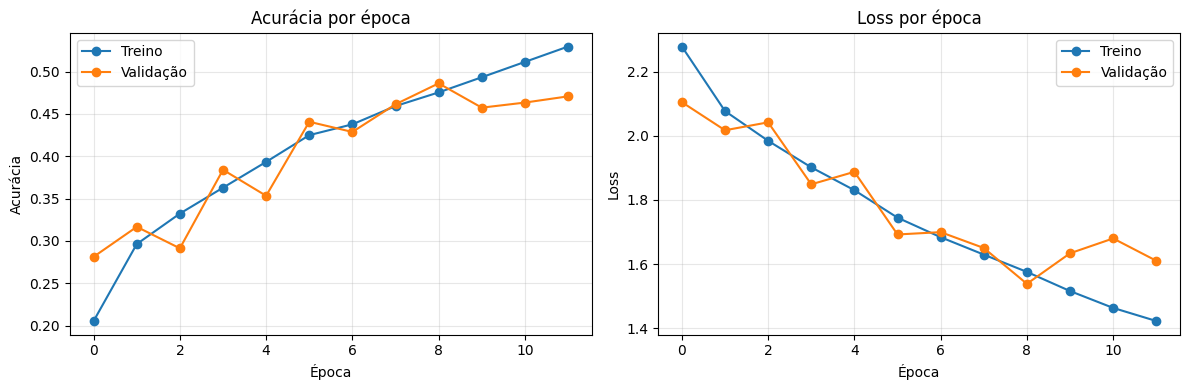

✅ Gap treino/validação controlado (5.9%).


In [ ]:
# Curvas de aprendizado: Acurácia e Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Treino", marker="o")
plt.plot(history.history["val_accuracy"], label="Validação", marker="o")
plt.title("Acurácia por época")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Treino", marker="o")
plt.plot(history.history["val_loss"], label="Validação", marker="o")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = history.history["accuracy"][-1] - history.history["val_accuracy"][-1]
if gap > 0.15:
    print(f"⚠️ Possível overfitting: acurácia de treino supera a de validação em {gap:.1%}.")
else:
    print(f"✅ Gap treino/validação controlado ({gap:.1%}).")


In [ ]:
# Avaliação final no conjunto de TESTE (nunca visto pelo modelo nem usado no EarlyStopping)
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"Loss no teste     : {test_loss:.4f}")
print(f"Acurácia no teste : {test_accuracy:.2%}")

acuracia_aleatoria = 1 / num_classes
print(f"\nReferência - acurácia de um classificador aleatório com {num_classes} classes: "
      f"{acuracia_aleatoria:.2%}")
print(f"Nosso modelo é {test_accuracy / acuracia_aleatoria:.1f}x melhor que o acaso.")


Loss no teste     : 1.5681
Acurácia no teste : 48.07%

Referência - acurácia de um classificador aleatório com 12 classes: 8.33%
Nosso modelo é 5.8x melhor que o acaso.


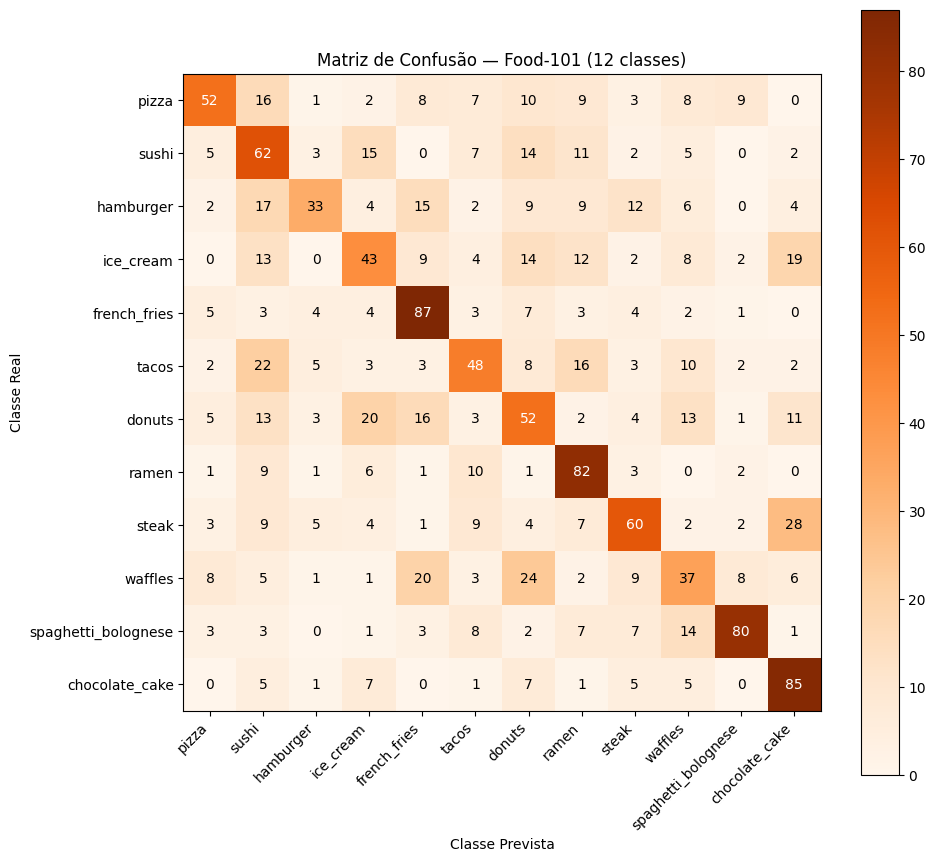

In [ ]:

# Matriz de Confusão
# A matriz de confusão permite analisar os acertos e erros de cada classe:
#   - Diagonal principal: classificações corretas.
#   - Fora da diagonal: classes que o modelo confundiu.

y_verdadeiro = []
y_pred_probs_lista = []

for imagens, rotulos in test_ds:
    previsoes_lote = model.predict(imagens, verbose=0)
    y_pred_probs_lista.append(previsoes_lote)
    y_verdadeiro.append(rotulos.numpy())

y_verdadeiro = np.concatenate(y_verdadeiro)
y_pred_probs = np.concatenate(y_pred_probs_lista)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

matriz_confusao = tf.math.confusion_matrix(y_verdadeiro, y_pred_classes).numpy()

plt.figure(figsize=(10, 9))
plt.imshow(matriz_confusao, cmap="Oranges")
plt.title("Matriz de Confusão — Food-101 (12 classes)")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)

plt.colorbar()

limiar = matriz_confusao.max() / 2
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j, i,
            matriz_confusao[i, j],
            ha="center", va="center",
            color="white" if matriz_confusao[i, j] > limiar else "black",
        )

plt.tight_layout()
plt.show()


In [ ]:
# Métricas por classe (precisão, recall, F1-score) e análise de confusões
print(f"{'Classe':<22}{'Precisão':>10}{'Recall':>10}{'F1-score':>10}")
print("-" * 52)

f1_scores = []
for i, nome in enumerate(class_names):
    vp = matriz_confusao[i, i]
    fp = matriz_confusao[:, i].sum() - vp
    fn = matriz_confusao[i, :].sum() - vp

    precisao = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    recall = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    f1 = 2 * precisao * recall / (precisao + recall) if (precisao + recall) > 0 else 0.0
    f1_scores.append(f1)

    print(f"{nome:<22}{precisao:>10.2%}{recall:>10.2%}{f1:>10.2%}")

print("-" * 52)
print(f"{'Média':<22}{'':>10}{'':>10}{np.mean(f1_scores):>10.2%}")

# Qual par de classes o modelo mais confunde?
matriz_sem_diagonal = matriz_confusao.copy()
np.fill_diagonal(matriz_sem_diagonal, 0)
i_real, j_prevista = np.unravel_index(np.argmax(matriz_sem_diagonal), matriz_sem_diagonal.shape)

print(
    f"\n🔎 Maior confusão observada: '{class_names[i_real]}' foi classificado como "
    f"'{class_names[j_prevista]}' em {matriz_sem_diagonal[i_real, j_prevista]} casos."
)
print("💡 Pratos com aparência/composição semelhante (cor, formato, apresentação) tendem "
      "a ser mais confundidos entre si — por exemplo, pratos com massa, molho vermelho, "
      "ou frituras de formato parecido.")

pior_classe_idx = int(np.argmin(f1_scores))
print(f"\n📉 Classe com pior F1-score: '{class_names[pior_classe_idx]}' "
      f"({f1_scores[pior_classe_idx]:.2%}) — candidata a receber mais dados ou "
      f"data augmentation mais agressivo em uma próxima iteração.")


Classe                  Precisão    Recall  F1-score
----------------------------------------------------
pizza                     60.47%    41.60%    49.29%
sushi                     35.03%    49.21%    40.92%
hamburger                 57.89%    29.20%    38.82%
ice_cream                 39.09%    34.13%    36.44%
french_fries              53.37%    70.73%    60.84%
tacos                     45.71%    38.71%    41.92%
donuts                    34.21%    36.36%    35.25%
ramen                     50.93%    70.69%    59.21%
steak                     52.63%    44.78%    48.39%
waffles                   33.64%    29.84%    31.62%
spaghetti_bolognese       74.77%    62.02%    67.80%
chocolate_cake            53.80%    72.65%    61.82%
----------------------------------------------------
Média                                         47.69%

🔎 Maior confusão observada: 'steak' foi classificado como 'chocolate_cake' em 28 casos.
💡 Pratos com aparência/composição semelhante (cor, formato, apr

## 7. Inferência com uma Imagem do Teste

### 🎯 Objetivo desta etapa
Escolher uma imagem específica do conjunto de teste, gerar a previsão do modelo e visualizar
o resultado junto com o nível de confiança e o Top-3 de classes mais prováveis.


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


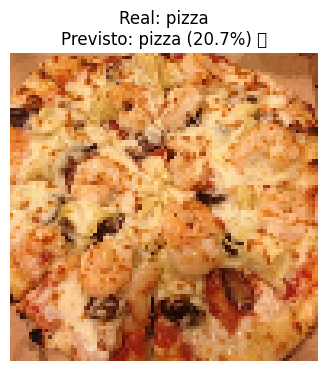

Top-3 previsões:
  1. pizza                  - 20.70%
  2. french_fries           - 14.32%
  3. tacos                  - 10.66%


In [ ]:
# Reconstrói o conjunto de teste "desempacotado" (sem batch) para acessar exemplos individuais
test_ds_unbatched = list(test_ds.unbatch().as_numpy_iterator())

indice = 5  # altere este valor para testar outras imagens

if not (0 <= indice < len(test_ds_unbatched)):
    raise IndexError(f"Índice {indice} fora do intervalo válido (0 a {len(test_ds_unbatched) - 1}).")

imagem, classe_real = test_ds_unbatched[indice]
classe_real = int(classe_real)

# Preparar para o modelo (adiciona a dimensão de batch)
imagem_modelo = np.expand_dims(imagem, axis=0)

# Fazer a previsão
previsoes = model.predict(imagem_modelo, verbose=0)
classe_prevista = int(np.argmax(previsoes))
confianca = float(np.max(previsoes))

acertou = "✅" if classe_prevista == classe_real else "❌"
plt.figure(figsize=(4, 4))
plt.imshow(imagem)
plt.title(
    f"Real: {class_names[classe_real]}\n"
    f"Previsto: {class_names[classe_prevista]} ({confianca:.1%}) {acertou}"
)
plt.axis("off")
plt.show()

# Top-3 previsões
top3_idx = np.argsort(previsoes[0])[::-1][:3]
print("Top-3 previsões:")
for rank, idx in enumerate(top3_idx, start=1):
    print(f"  {rank}. {class_names[idx]:<22} - {previsoes[0][idx]:.2%}")


## 8. Inferência com uma Imagem Externa

### 🎯 Objetivo desta etapa
Testar o modelo com uma foto que **não faz parte do Food-101** — por exemplo, uma foto tirada
por você mesmo(a), ou baixada da internet. É o teste mais próximo de um uso real do modelo.

### 📚 Por que o pré-processamento precisa ser idêntico ao do treino?
O modelo foi treinado com imagens de `96x96` pixels, normalizadas para o intervalo `[0, 1]`.
Se a imagem externa não passar exatamente pelas mesmas transformações (mesmo tamanho, mesma
escala de valores, mesma ordem de canais RGB), o modelo pode fazer previsões sem sentido —
não porque o modelo é ruim, mas porque a entrada não está no formato que ele "entende".

### 🛠️ Como testar com a sua própria imagem (passo a passo)
1. Rode a célula abaixo — ela abre um botão de **upload** (funciona no Google Colab);
2. Selecione uma foto do seu computador (idealmente mostrando claramente um dos 12 alimentos
   do notebook: pizza, sushi, hambúrguer, sorvete, batata frita, tacos, donut, ramen, bife,
   waffle, espaguete à bolonhesa ou bolo de chocolate);
3. A célula redimensiona, normaliza e envia a imagem ao modelo automaticamente;
4. O resultado (classe prevista + confiança + Top-3) é exibido logo abaixo.

> 💡 **Alternativa sem upload interativo:** se preferir, salve sua imagem no ambiente do Colab
> (ex.: arraste o arquivo para a aba "Arquivos" à esquerda) e troque a linha
> `caminho_imagem = ...` pelo caminho do arquivo, pulando a célula de upload.


In [ ]:
try:
    from google.colab import files
    print("Selecione um arquivo de imagem (.jpg, .jpeg ou .png):")
    arquivos_enviados = files.upload()
    caminho_imagem = list(arquivos_enviados.keys())[0]
except ImportError:
    # Ambiente local: defina o caminho manualmente antes de rodar esta célula
    caminho_imagem = "minha_foto.jpg"
    print(f"Ambiente não é o Google Colab. Usando caminho manual: {caminho_imagem}")

print("Imagem selecionada:", caminho_imagem)


Selecione um arquivo de imagem (.jpg, .jpeg ou .png):


Saving Bolo.jpeg to Bolo.jpeg
Imagem selecionada: Bolo.jpeg


In [ ]:
# Pré-processamento da imagem externa (idêntico ao usado no treinamento)
import os

if not os.path.exists(caminho_imagem):
    raise FileNotFoundError(
        f"Arquivo '{caminho_imagem}' não encontrado. Verifique se o upload funcionou "
        f"ou se o caminho está correto."
    )

# Carrega a imagem já redimensionada para o tamanho esperado pelo modelo
img_externa = tf.keras.utils.load_img(caminho_imagem, target_size=(IMG_SIZE, IMG_SIZE))

# Converte para array e aplica a MESMA normalização usada no treino (0-1)
img_array = tf.keras.utils.img_to_array(img_externa)
img_array = img_array / 255.0
img_array_modelo = np.expand_dims(img_array, axis=0)  # adiciona dimensão de batch

# Verificação explícita do shape antes de prever
shape_esperado = (1, IMG_SIZE, IMG_SIZE, 3)
if img_array_modelo.shape != shape_esperado:
    raise ValueError(
        f"Shape inesperado {img_array_modelo.shape}, esperado {shape_esperado}."
    )

print("✅ Imagem pré-processada com sucesso. Shape:", img_array_modelo.shape)


✅ Imagem pré-processada com sucesso. Shape: (1, 96, 96, 3)


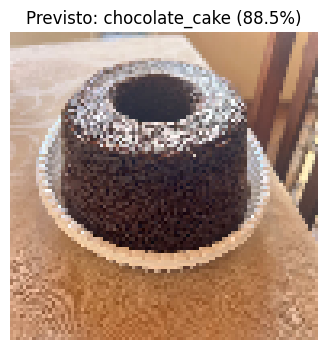

Top-3 previsões:
  1. chocolate_cake         - 88.46%
  2. donuts                 - 6.07%
  3. ice_cream              - 3.36%


In [ ]:
# Previsão e visualização do resultado
previsoes = model.predict(img_array_modelo, verbose=0)
classe_prevista = int(np.argmax(previsoes))
confianca = float(np.max(previsoes))

plt.figure(figsize=(4, 4))
plt.imshow(img_externa)
plt.title(f"Previsto: {class_names[classe_prevista]} ({confianca:.1%})")
plt.axis("off")
plt.show()

# Top-3 previsões, para entender o quão "decidido" o modelo estava
top3_idx = np.argsort(previsoes[0])[::-1][:3]
print("Top-3 previsões:")
for rank, idx in enumerate(top3_idx, start=1):
    print(f"  {rank}. {class_names[idx]:<22} - {previsoes[0][idx]:.2%}")

if confianca < 0.4:
    print(
        "\n⚠️ Confiança baixa: a imagem pode não corresponder claramente a nenhuma das "
        "12 classes treinadas, pode estar em um ângulo/iluminação muito diferente do "
        "padrão do Food-101, ou o alimento pode simplesmente não estar entre as 12 classes."
    )



Parabéns por concluir este pipeline completo de classificação de alimentos! 🍽️🎉

**Fim!** 🍕🍣🍔
